In [27]:
import pandas as pd

# Load the dataset
df = pd.read_csv('../data/benin-malanville.csv') 

In [28]:
# Display the first few rows
print(df.head())

# Get basic statistics
print(df.describe())

# Check for missing values
print(df.isnull().sum())

          Timestamp  GHI  DNI  DHI  ModA  ModB  Tamb    RH   WS  WSgust  \
0  2021-08-09 00:01 -1.2 -0.2 -1.1   0.0   0.0  26.2  93.4  0.0     0.4   
1  2021-08-09 00:02 -1.1 -0.2 -1.1   0.0   0.0  26.2  93.6  0.0     0.0   
2  2021-08-09 00:03 -1.1 -0.2 -1.1   0.0   0.0  26.2  93.7  0.3     1.1   
3  2021-08-09 00:04 -1.1 -0.1 -1.0   0.0   0.0  26.2  93.3  0.2     0.7   
4  2021-08-09 00:05 -1.0 -0.1 -1.0   0.0   0.0  26.2  93.3  0.1     0.7   

   WSstdev     WD  WDstdev   BP  Cleaning  Precipitation  TModA  TModB  \
0      0.1  122.1      0.0  998         0            0.0   26.3   26.2   
1      0.0    0.0      0.0  998         0            0.0   26.3   26.2   
2      0.5  124.6      1.5  997         0            0.0   26.4   26.2   
3      0.4  120.3      1.3  997         0            0.0   26.4   26.3   
4      0.3  113.2      1.0  997         0            0.0   26.4   26.3   

   Comments  
0       NaN  
1       NaN  
2       NaN  
3       NaN  
4       NaN  
                 GHI

In [12]:
print(df.shape)

(525600, 18)


In [20]:
df = pd.read_csv("../data/benin-malanville.csv", parse_dates=True)
print(df.head())


          Timestamp  GHI  DNI  DHI  ModA  ModB  Tamb    RH   WS  WSgust  \
0  2021-08-09 00:01 -1.2 -0.2 -1.1   0.0   0.0  26.2  93.4  0.0     0.4   
1  2021-08-09 00:02 -1.1 -0.2 -1.1   0.0   0.0  26.2  93.6  0.0     0.0   
2  2021-08-09 00:03 -1.1 -0.2 -1.1   0.0   0.0  26.2  93.7  0.3     1.1   
3  2021-08-09 00:04 -1.1 -0.1 -1.0   0.0   0.0  26.2  93.3  0.2     0.7   
4  2021-08-09 00:05 -1.0 -0.1 -1.0   0.0   0.0  26.2  93.3  0.1     0.7   

   WSstdev     WD  WDstdev   BP  Cleaning  Precipitation  TModA  TModB  \
0      0.1  122.1      0.0  998         0            0.0   26.3   26.2   
1      0.0    0.0      0.0  998         0            0.0   26.3   26.2   
2      0.5  124.6      1.5  997         0            0.0   26.4   26.2   
3      0.4  120.3      1.3  997         0            0.0   26.4   26.3   
4      0.3  113.2      1.0  997         0            0.0   26.4   26.3   

   Comments  
0       NaN  
1       NaN  
2       NaN  
3       NaN  
4       NaN  


In [21]:
df_sample = df.sample(n=1000)  # Use 1000 random rows
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

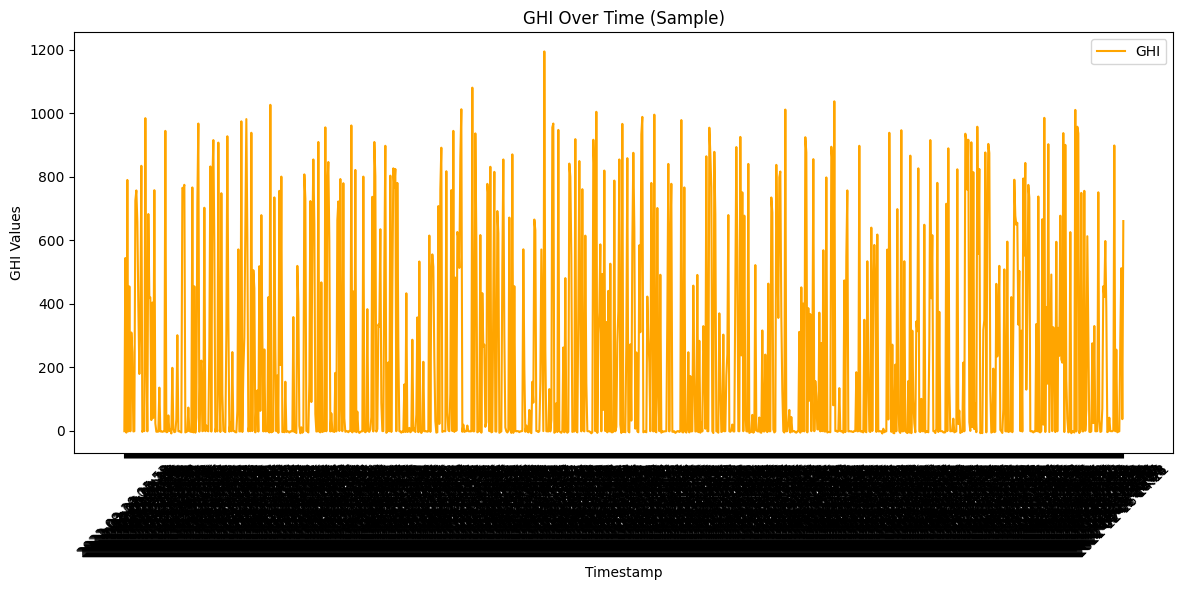

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df_sample['Timestamp'], df_sample['GHI'], label='GHI', color='orange')
plt.xlabel('Timestamp')
plt.ylabel('GHI Values')
plt.title('GHI Over Time (Sample)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

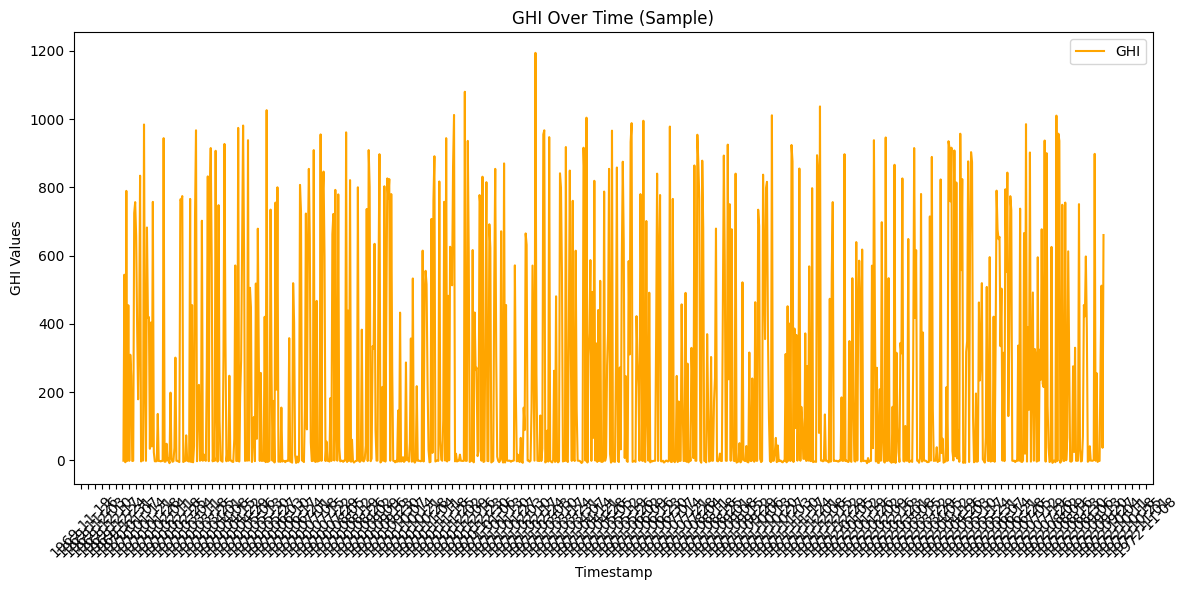

In [23]:
import matplotlib.dates as mdates

plt.figure(figsize=(12, 6))
plt.plot(df_sample['Timestamp'], df_sample['GHI'], label='GHI', color='orange')
plt.xlabel('Timestamp')
plt.ylabel('GHI Values')
plt.title('GHI Over Time (Sample)')
plt.legend()

# Set major ticks to every 7 days
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))  # Major ticks every week
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Format dates

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

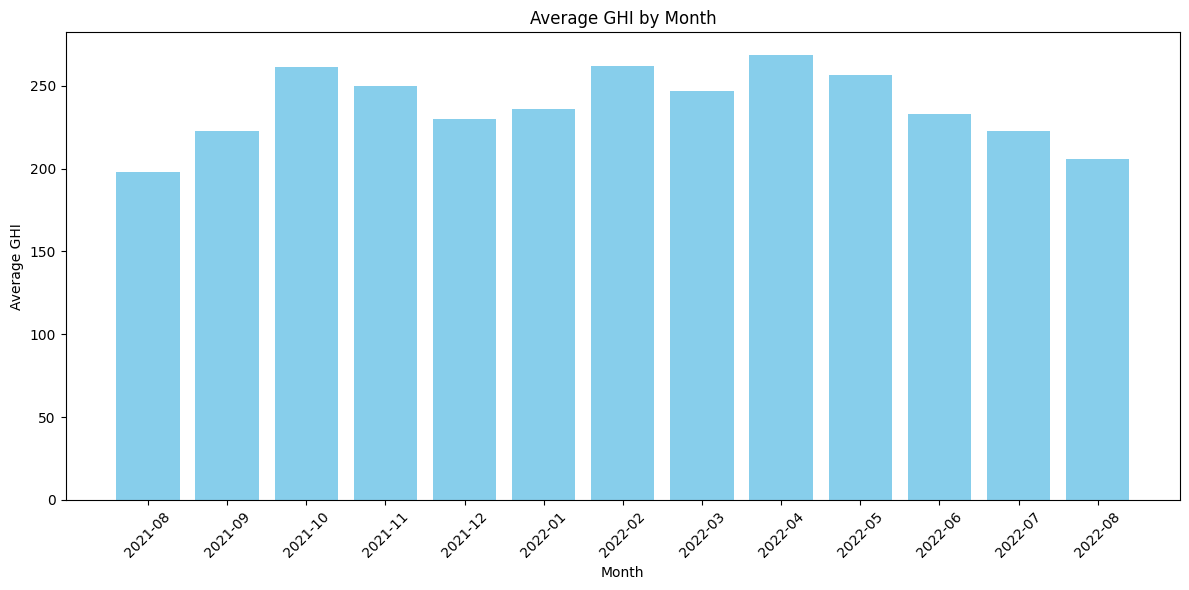

In [24]:
df['Date'] = pd.to_datetime(df['Timestamp']).dt.to_period('M')

monthly_avg = df.groupby('Date')['GHI'].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.bar(monthly_avg['Date'].astype(str), monthly_avg['GHI'], color='skyblue')
plt.xlabel('Month')
plt.ylabel('Average GHI')
plt.title('Average GHI by Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

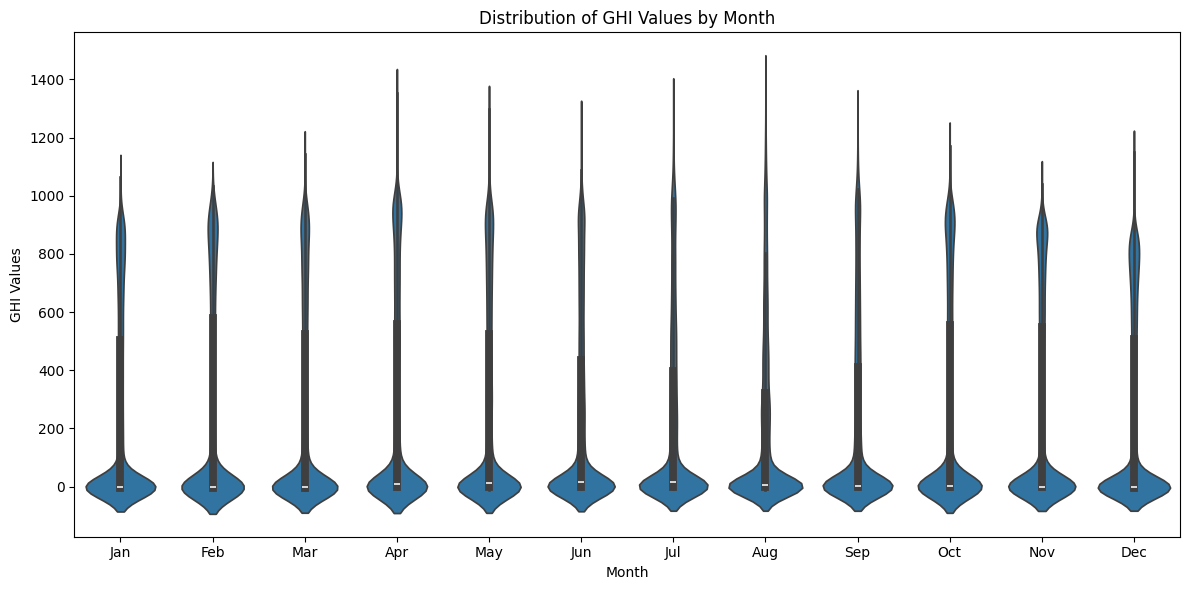

In [25]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.violinplot(x=df['Date'].dt.month, y='GHI', data=df)
plt.xlabel('Month')
plt.ylabel('GHI Values')
plt.title('Distribution of GHI Values by Month')
plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.tight_layout()
plt.show()

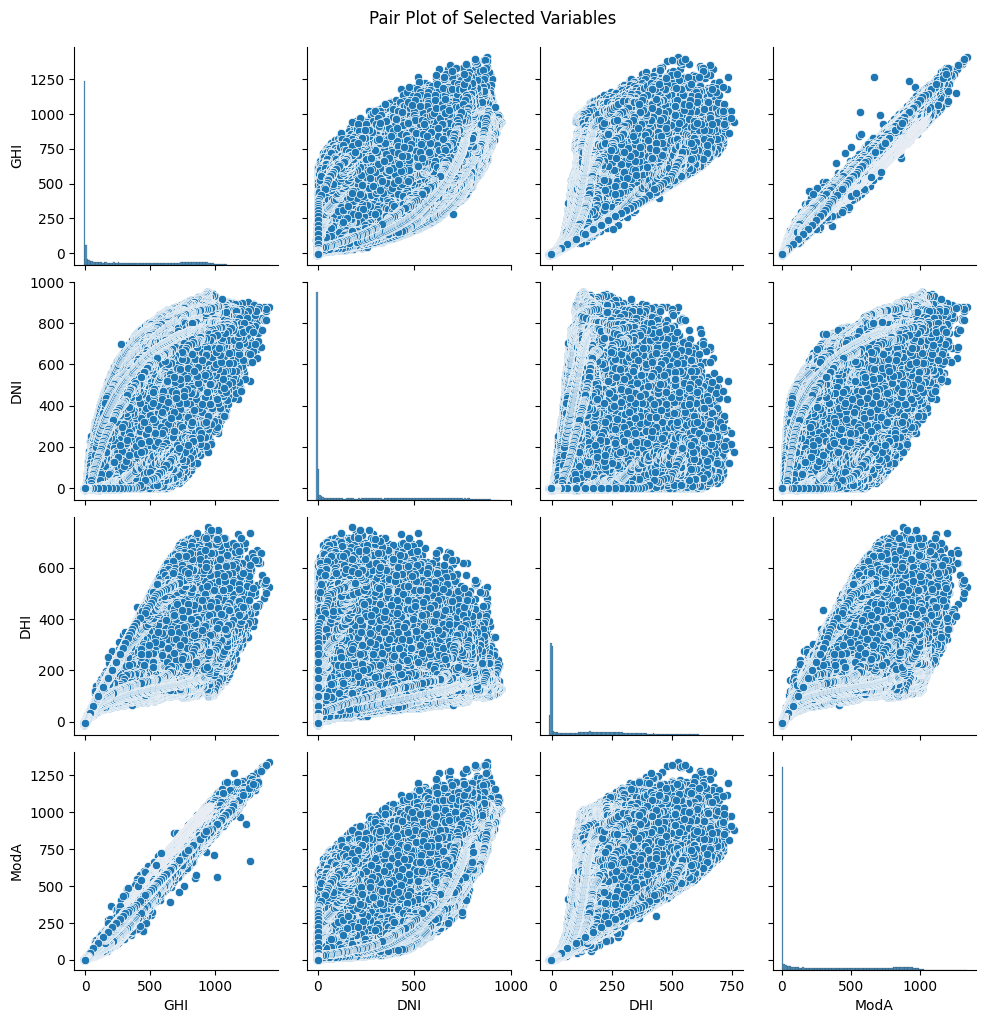

In [26]:
sns.pairplot(df[['GHI', 'DNI', 'DHI', 'ModA']])  # Adjust with relevant columns
plt.suptitle('Pair Plot of Selected Variables', y=1.02)
plt.show()